# HBB: whole vs. sum of parts (AlphaGenome, GTEx whole blood)

## Imports

In [1]:
import dataclasses

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.visualization import plot_transcripts

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
sns.set_context("notebook")

TRACK_NAME = "UBERON:0013756 gtex Whole_Blood polyA plus RNA-seq"
TRACK_STRAND = "."
HBB_GENE_ID = "ENSG00000244734"
CHROMOSOME = "chr11"

## Data

In [2]:
SCALE = "full"
ROOT = ".."
WHOLE_VS_SUM_PARTS = f"{ROOT}/results/03-analysis/hbb_wholeblood/whole_vs_sum_parts.{SCALE}.parquet"
GTF_PARQUET = f"{ROOT}/data/raw/GENCODE/release_46/gencode.v46.annotation.gtf.parquet"

WINDOW = {"dev": (5221202, 5237586), "full": (4705106, 5753682)}[SCALE]
INTERVAL = genome.Interval(CHROMOSOME, *WINDOW)

con = duckdb.connect()
combined = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [WHOLE_VS_SUM_PARTS, TRACK_NAME, TRACK_STRAND],
).df()

# 1000 Genomes population/ancestry panel (IGSR/NYGC, matches this cohort's sample
# IDs exactly) - read directly via pandas from the URL rather than adding a new
# Snakemake download rule, since it's a small, static, publicly hosted text file.
POPULATION_PANEL_URL = (
    "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/"
    "1000G_2504_high_coverage/20130606_g1k_3202_samples_ped_population.txt"
)
population = pd.read_csv(POPULATION_PANEL_URL, sep=r"\s+")
combined = combined.merge(
    population[["SampleID", "Population", "Superpopulation"]],
    left_on="sample", right_on="SampleID", how="left",
).drop(columns="SampleID")

len(combined), combined["Superpopulation"].isna().sum()

(1842, np.int64(0))

## Gene annotation

In [3]:
gtf = pd.read_parquet(GTF_PARQUET)
gtf_coding = gene_annotation.filter_protein_coding(gtf)
gtf_coding = gene_annotation.filter_to_longest_transcript(gtf_coding)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_coding)

transcripts_overview = transcript_extractor.extract(INTERVAL)
hbb_transcript = next(
    t for t in transcripts_overview if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID
)
hbb_start, hbb_end = hbb_transcript.transcript_interval.start, hbb_transcript.transcript_interval.end

ZOOM_PAD = 5000
ZOOM_INTERVAL = genome.Interval(CHROMOSOME, hbb_start - ZOOM_PAD, hbb_end + ZOOM_PAD)
transcripts_zoom = transcript_extractor.extract(ZOOM_INTERVAL)

len(transcripts_overview), len(transcripts_zoom)

/users/diasfrazer/manglada/projects/wigttsoip/src/alphagenome/src/alphagenome/data/transcript.py:661: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


(42, 2)

## Genomic annotation: 1Mb overview and HBB zoom

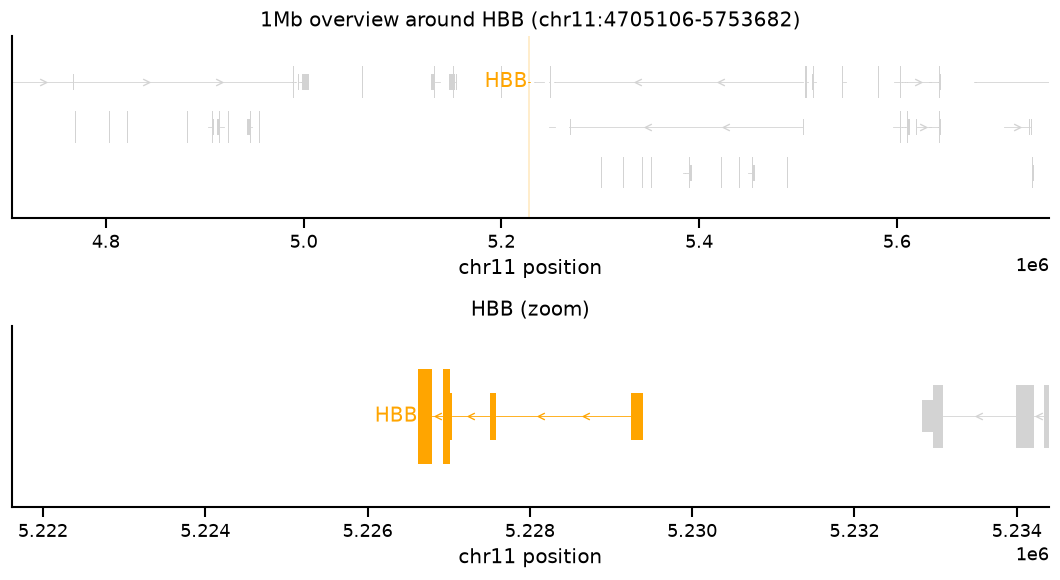

In [4]:
GRAY_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="lightgray", utr5_color="lightgray", utr3_color="lightgray",
    first_noncoding_exon_color="lightgray", label_color="gray",
)
ORANGE_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="orange", utr5_color="orange", utr3_color="orange",
    first_noncoding_exon_color="orange", label_color="orange",
)


def draw_gene_track(ax, transcripts, interval, cds_scale=1.0):
    hbb = [t for t in transcripts if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID]
    others = [t for t in transcripts if t not in hbb]
    heights = plot_transcripts._get_placement_heights(transcripts, extend_fraction=1.0)
    for t in others:
        plot_transcripts.draw_transcript(
            ax=ax, transcript=t, interval=interval, y=heights[t.transcript_id],
            cds_height=GRAY_STYLE.cds_height, utr_height=GRAY_STYLE.utr_height,
            cds_color=GRAY_STYLE.cds_color, utr5_color=GRAY_STYLE.utr5_color,
            utr3_color=GRAY_STYLE.utr3_color,
            first_noncoding_exon_color=GRAY_STYLE.first_noncoding_exon_color,
            label_color=GRAY_STYLE.label_color, label=None, zorder=1,
        )
    for t in hbb:
        plot_transcripts.draw_transcript(
            ax=ax, transcript=t, interval=interval, y=heights[t.transcript_id],
            cds_height=ORANGE_STYLE.cds_height * cds_scale, utr_height=ORANGE_STYLE.utr_height * cds_scale,
            cds_color=ORANGE_STYLE.cds_color, utr5_color=ORANGE_STYLE.utr5_color,
            utr3_color=ORANGE_STYLE.utr3_color,
            first_noncoding_exon_color=ORANGE_STYLE.first_noncoding_exon_color,
            label_color=ORANGE_STYLE.label_color, label="HBB", zorder=2,
        )
    ax.set_xlim(interval.start, interval.end)
    ax.set_ylim(min(heights.values()) - 1, max(heights.values()) + 1)
    ax.set_yticks([])
    ax.set_xlabel(f"{CHROMOSOME} position")


fig, (ax_overview, ax_zoom) = plt.subplots(2, 1, figsize=(9, 5))

draw_gene_track(ax_overview, transcripts_overview, INTERVAL, cds_scale=1.0)
ax_overview.axvspan(hbb_start, hbb_end, color="orange", alpha=0.2, zorder=0, lw=0)
ax_overview.set_title(f"1Mb overview around HBB ({CHROMOSOME}:{INTERVAL.start}-{INTERVAL.end})")

draw_gene_track(ax_zoom, transcripts_zoom, ZOOM_INTERVAL, cds_scale=1.5)
ax_zoom.set_title("HBB (zoom)")

fig.tight_layout()

## Variant burden per individual

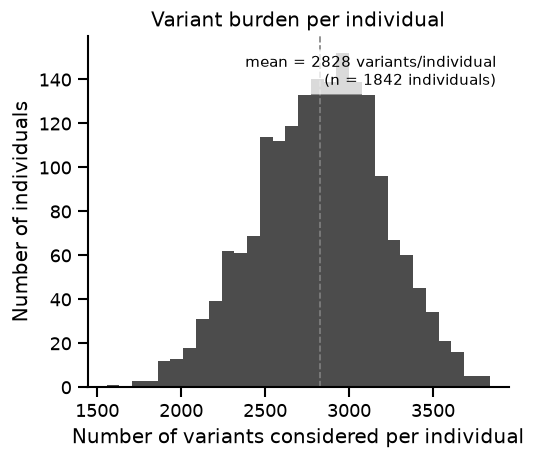

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hist(combined["n_variants_matched"], bins=30, color="black", alpha=0.7)
mean_n = combined["n_variants_matched"].mean()
ax.axvline(mean_n, color="gray", lw=1, ls="--")
ax.text(
    0.97, 0.95, f"mean = {mean_n:.0f} variants/individual\n(n = {len(combined)} individuals)",
    transform=ax.transAxes, ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.8),
)
ax.set_xlabel("Number of variants considered per individual")
ax.set_ylabel("Number of individuals")
ax.set_title("Variant burden per individual")
fig.tight_layout()

## Combined (whole) effect distribution

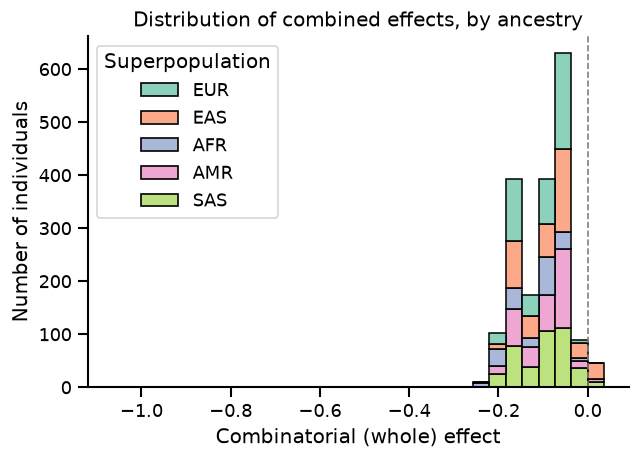

In [6]:
# 1000 Genomes IGSR/NYGC population panel (see ## Data) confirms these individuals do
# have ancestry labels - hued below by continental ancestry (Superpopulation).
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.histplot(
    data=combined, x="whole_score", hue="Superpopulation", bins=30,
    multiple="stack", palette="Set2", ax=ax,
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Combinatorial (whole) effect")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of combined effects, by ancestry")
fig.tight_layout()

## Sum of independent effects distribution

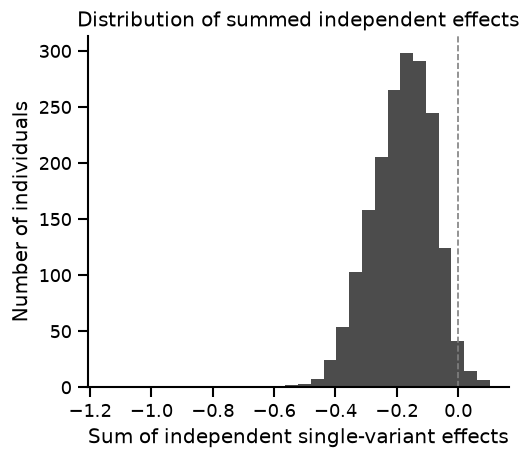

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hist(combined["sum_parts_score"], bins=30, color="black", alpha=0.7)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Sum of independent single-variant effects")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of summed independent effects")
fig.tight_layout()

## Combined vs. sum of independent effects

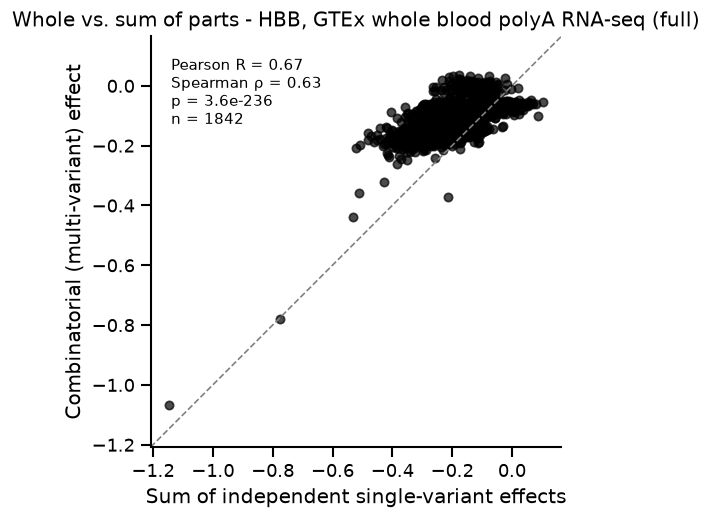

In [8]:
x = combined["sum_parts_score"].to_numpy()
y = combined["whole_score"].to_numpy()
r, p = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)
n = len(combined)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x, y, s=25, color="black", alpha=0.7)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Sum of independent single-variant effects")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title(f"Whole vs. sum of parts - HBB, GTEx whole blood polyA RNA-seq ({SCALE})")
ax.text(
    0.05, 0.95, f"Pearson R = {r:.2f}\nSpearman ρ = {rho:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
fig.tight_layout()

## Squashing: |combined| vs. |sum of independent effects|

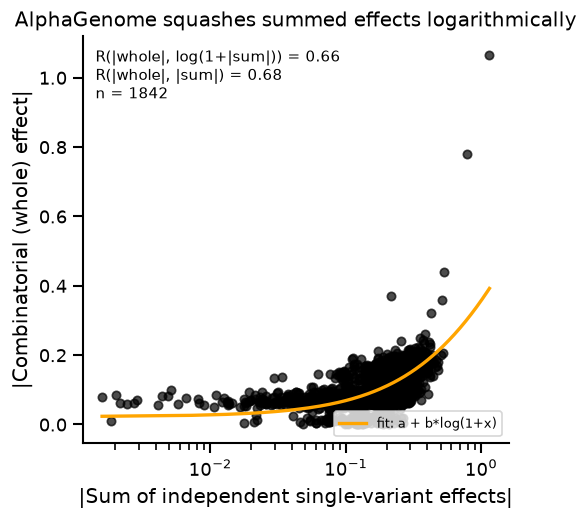

In [9]:
abs_x = combined["sum_parts_score"].abs().to_numpy()
abs_y = combined["whole_score"].abs().to_numpy()
log_x = np.log1p(abs_x)

slope, intercept, r_log, p_log, _ = stats.linregress(log_x, abs_y)
r_lin, p_lin = stats.pearsonr(abs_x, abs_y)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(abs_x, abs_y, s=25, color="black", alpha=0.7)

x_curve = np.linspace(abs_x.min(), abs_x.max(), 200)
y_curve = intercept + slope * np.log1p(x_curve)
ax.plot(x_curve, y_curve, color="orange", lw=2, label="fit: a + b*log(1+x)")

ax.set_xscale("log")
ax.set_xlabel("|Sum of independent single-variant effects|")
ax.set_ylabel("|Combinatorial (whole) effect|")
ax.set_title("AlphaGenome squashes summed effects logarithmically")
ax.text(
    0.03, 0.97,
    f"R(|whole|, log(1+|sum|)) = {r_log:.2f}\nR(|whole|, |sum|) = {r_lin:.2f}\nn = {len(combined)}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()